<a href="https://colab.research.google.com/github/ASNAS256/MuniLabs-AI-Workspace/blob/asikus/curebench_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 CureBench EDA — Track 2: Agentic Tool-Augmented Reasoning

This notebook walks through a complete **Exploratory Data Analysis** of the three CureBench datasets:
- `curebench_valset_phase1.jsonl` — **459 labelled questions** (your ground truth for local eval)
- `curebench_testset_phase1.jsonl` — **2,079 unlabelled questions** (Phase 1 submission target)
- `curebench_testset_phase2.jsonl` — **2,491 unlabelled questions** (Phase 2 submission target)

**Goals of this EDA:**
1. Understand dataset structure and size
2. Identify question type distribution
3. Detect label imbalance (answer bias)
4. Categorize clinical topics → tells you which APIs to build
5. Measure question complexity → tells you how powerful your LLM backbone needs to be
6. Establish a naive baseline (floor)
7. Run zero-shot LLM baseline (ceiling without tools)
8. Error analysis → direct engineering roadmap

## 📦 Step 0 — Setup & Imports

In [ ]:
# Install dependencies
!pip install pandas matplotlib seaborn wordcloud -q

import json # For handling JSON data, particularly useful for loading .jsonl files
import re # For regular expression operations, used in text processing like word clouds
import pandas as pd # For data manipulation and analysis, especially with DataFrames
import matplotlib.pyplot as plt # For creating static, interactive, and animated visualizations
import matplotlib.ticker as mtick # For advanced tick control in matplotlib plots
import seaborn as sns # For making attractive and informative statistical graphics based on matplotlib
from collections import Counter, defaultdict # Counter for counting hashable objects, defaultdict for dictionary with default values
from wordcloud import WordCloud # For generating word cloud images

# Style
sns.set_theme(style='whitegrid', palette='muted') # Sets a consistent aesthetic style for plots
plt.rcParams['figure.dpi'] = 120 # Sets the resolution of generated figures
print('Setup complete')

Setup complete


## 📂 Step 1 — Upload & Load the Datasets

Upload the three `.jsonl` files using the Colab file browser (left sidebar → Files → Upload), then run the cell below.

In [ ]:
# ── If running in Colab, upload files first, then update paths below ──
# from google.colab import files
# uploaded = files.upload()  # uncomment to use Colab uploader

VAL_PATH  = 'curebench_valset_pharse1.jsonl'      # 459 labelled
TEST1_PATH = 'curebench_testset_phase1.jsonl'      # 2079 unlabelled
TEST2_PATH = 'curebench_testset_phase2.jsonl'      # 2491 unlabelled

def load_jsonl(path):
    records = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

val_raw   = load_jsonl(VAL_PATH)
test1_raw = load_jsonl(TEST1_PATH)
test2_raw = load_jsonl(TEST2_PATH)

# Convert to DataFrames
def records_to_df(records):
    rows = []
    for r in records:
        rows.append({
            'id':            r['id'],
            'question_type': r['question_type'],
            'question':      r['question'],
            'options':       r.get('options', {}),
            'correct_answer': r.get('correct_answer', None),
            'q_word_count':  len(r['question'].split()),
            'num_options':   len(r.get('options', {})),
        })
    return pd.DataFrame(rows)

val   = records_to_df(val_raw)
test1 = records_to_df(test1_raw)
test2 = records_to_df(test2_raw)

print(f'Val set:     {len(val):,} rows | labelled: {val.correct_answer.notna().sum()}')
print(f'Test Phase1: {len(test1):,} rows | labelled: {test1.correct_answer.notna().sum()}')
print(f'Test Phase2: {len(test2):,} rows | labelled: {test2.correct_answer.notna().sum()}')
val.head(3)

Val set:     459 rows | labelled: 459
Test Phase1: 2,079 rows | labelled: 0
Test Phase2: 2,491 rows | labelled: 0


,id,question_type,question,options,correct_answer,q_word_count,num_options
0,U9PHZ83RKYV8,multi_choice,Which drug brand name is associated with the t...,"{'A': 'Salicylic Acid', 'B': 'Minoxidil', 'C':...",A,11,4
1,vIGwm8qguXYi,open_ended_multi_choice,What should patients do if they experience sev...,{'A': 'Wait for the symptoms to resolve on the...,B,17,4
2,GlpDnJvMaWbs,open_ended_multi_choice,What should you do if the dose indicator on St...,{'A': 'Continue using the inhaler until the ca...,B,13,4


## 🔍 Step 2 — Dataset Structure & Schema Check

In [ ]:
print('=== SCHEMA COMPARISON ===')
for name, raw in [('val', val_raw), ('test1', test1_raw), ('test2', test2_raw)]:
    keys = set(raw[0].keys())
    print(f'{name:8s}: fields = {sorted(keys)}')

print()
print('=== KEY DIFFERENCES ===')
print('- Val set has  correct_answer  → use for local evaluation & error analysis')
print('- Test sets have NO correct_answer → these are your submission targets')
print('- Phase 2 is harder (longer questions, more clinical scenarios)')

print()
print('=== MISSING VALUES ===')
for name, df in [('val', val), ('test1', test1), ('test2', test2)]:
    print(f'{name}: {df.isnull().sum().to_dict()}')

=== SCHEMA COMPARISON ===
val     : fields = ['correct_answer', 'id', 'options', 'question', 'question_type']
test1   : fields = ['id', 'options', 'question', 'question_type']
test2   : fields = ['id', 'options', 'question', 'question_type']

=== KEY DIFFERENCES ===
- Val set has  correct_answer  → use for local evaluation & error analysis
- Test sets have NO correct_answer → these are your submission targets
- Phase 2 is harder (longer questions, more clinical scenarios)

=== MISSING VALUES ===
val: {'id': 0, 'question_type': 0, 'question': 0, 'options': 0, 'correct_answer': 0, 'q_word_count': 0, 'num_options': 0}
test1: {'id': 0, 'question_type': 0, 'question': 0, 'options': 0, 'correct_answer': 2079, 'q_word_count': 0, 'num_options': 0}
test2: {'id': 0, 'question_type': 0, 'question': 0, 'options': 0, 'correct_answer': 2491, 'q_word_count': 0, 'num_options': 0}


## 📊 Step 3 — Question Type Distribution

There are **3 question types** in this dataset. Understanding their distribution tells you how to weight your agent's strategies:
- `multi_choice` — factual recall, usually short, needs drug label lookup
- `open_ended_multi_choice` — clinical reasoning with options, needs multi-step tool use
- `open_ended` — complex patient scenarios, needs the strongest reasoning backbone

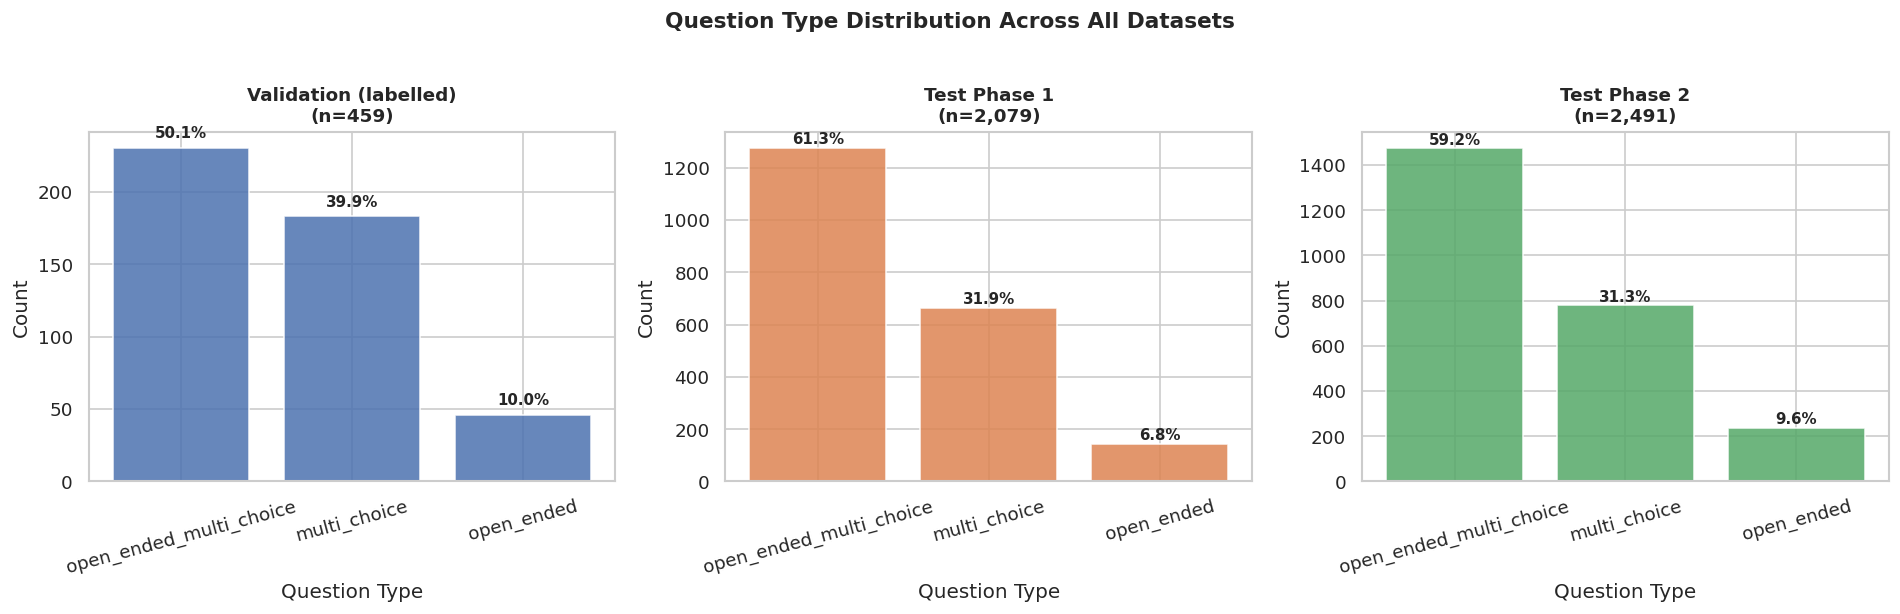


⚠️  KEY INSIGHT:
open_ended questions are the hardest — pure clinical reasoning with no easy recall.
Phase 2 has more of them. Your LLM backbone must handle long, multi-condition scenarios.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datasets = [('Validation (labelled)', val), ('Test Phase 1', test1), ('Test Phase 2', test2)]
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, (name, df), color in zip(axes, datasets, colors):
    counts = df['question_type'].value_counts()
    pcts   = df['question_type'].value_counts(normalize=True) * 100
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{name}\n(n={len(df):,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Question Type Distribution Across All Datasets', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('question_type_dist.png', bbox_inches='tight')
plt.show()

print('\n⚠️  KEY INSIGHT:')
print('open_ended questions are the hardest — pure clinical reasoning with no easy recall.')
print('Phase 2 has more of them. Your LLM backbone must handle long, multi-condition scenarios.')

## ⚖️ Step 4 — Answer Label Distribution (Bias Check)

If answers are heavily skewed toward one letter, a naive model can score well without understanding anything. You need to know this **before** evaluating any system.

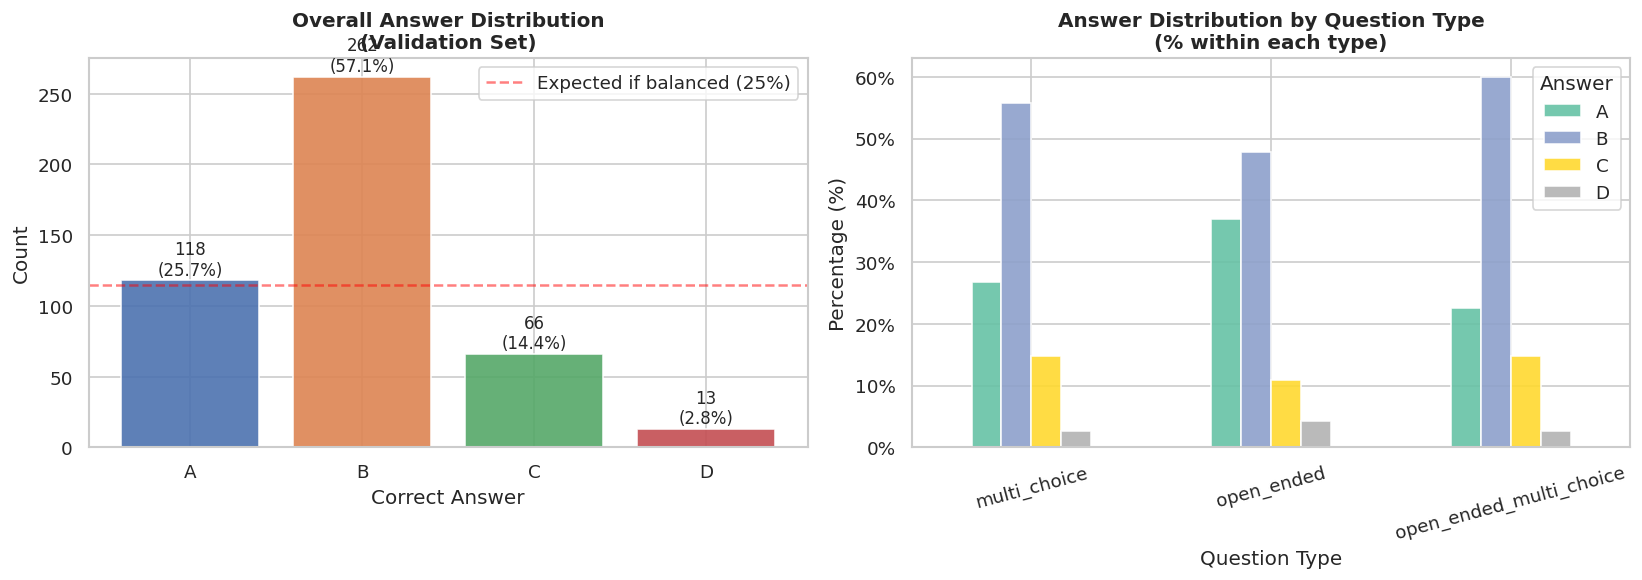


⚠️  LABEL IMBALANCE ALERT:
Most common answer: "B" appears 262 times (57.1%)
Naive baseline (always predict "B"): 57.1% accuracy
Random baseline: ~25.0% accuracy

→ Any system MUST beat 57.1% to be meaningful.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ans_counts = val['correct_answer'].value_counts().sort_index()
bars = axes[0].bar(ans_counts.index, ans_counts.values, color=['#4C72B0','#DD8452','#55A868','#C44E52'],
                   edgecolor='white', alpha=0.9)
for bar, val_count in zip(bars, ans_counts.values):
    pct = val_count / len(val) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val_count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_title('Overall Answer Distribution\n(Validation Set)', fontweight='bold')
axes[0].set_xlabel('Correct Answer')
axes[0].set_ylabel('Count')
axes[0].axhline(y=len(val)/4, color='red', linestyle='--', alpha=0.5, label='Expected if balanced (25%)')
axes[0].legend()

# By question type
pivot = val.groupby(['question_type', 'correct_answer']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', alpha=0.9)
axes[1].set_title('Answer Distribution by Question Type\n(% within each type)', fontweight='bold')
axes[1].set_xlabel('Question Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Answer')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('answer_distribution.png', bbox_inches='tight')
plt.show()

# Naive baseline calculation
most_common_answer = val['correct_answer'].mode()[0]
naive_acc = (val['correct_answer'] == most_common_answer).mean()
print(f'\n⚠️  LABEL IMBALANCE ALERT:')
print(f'Most common answer: "{most_common_answer}" appears {ans_counts[most_common_answer]} times ({ans_counts[most_common_answer]/len(val)*100:.1f}%)')
print(f'Naive baseline (always predict "{most_common_answer}"): {naive_acc:.1%} accuracy')
print(f'Random baseline: ~25.0% accuracy')
print(f'\n→ Any system MUST beat {naive_acc:.1%} to be meaningful.')

## 🏥 Step 5 — Clinical Topic Categorization

This tells you **which external APIs to prioritize building** for your agent.
Each topic maps to specific data sources:

| Topic | Best API |
|-------|----------|
| adverse_events | OpenFDA, DailyMed |
| dosing | DailyMed, DrugBank |
| contraindications | OpenFDA drug labels |
| drug_interactions | DrugBank, OpenFDA |
| clinical_scenarios | All APIs + strong LLM reasoning |
| pregnancy_lactation | FDA drug labels (category info) |
| mechanism | DrugBank, ChEMBL |
| monitoring | Drug labels, clinical guidelines |

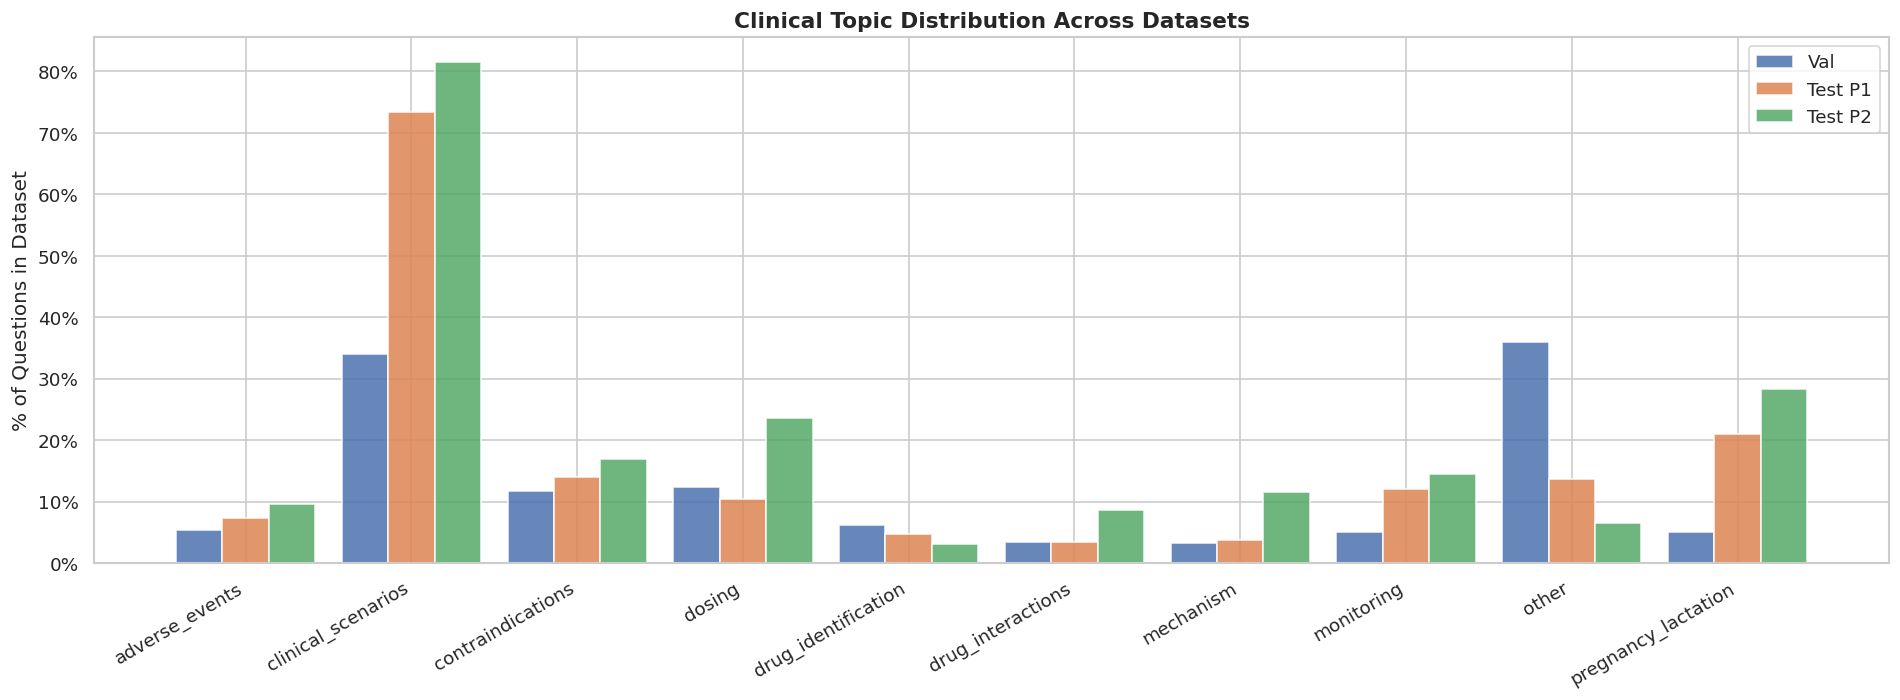


🔑 API PRIORITY BASED ON TOPIC FREQUENCY (Test Phase 2):
  clinical_scenarios        2030 (81.5%)
  pregnancy_lactation        705 (28.3%)
  dosing                     586 (23.5%)
  contraindications          421 (16.9%)
  monitoring                 362 (14.5%)
  mechanism                  287 (11.5%)
  adverse_events             239 (9.6%)
  drug_interactions          213 (8.6%)
  other                      162 (6.5%)
  drug_identification         75 (3.0%)


In [ ]:
TOPIC_KEYWORDS = {
    'adverse_events':       ['adverse', 'side effect', 'reaction', 'toxicity', 'warning',
                             'hypersensitivity', 'allergic', 'intolerance'],
    'dosing':               ['dose', 'dosing', 'mg', 'frequency', 'administration',
                             'missed dose', 'titration', 'regimen'],
    'contraindications':    ['contraindic', 'should not', 'avoid', 'prohibited',
                             'precaution', 'not recommended'],
    'drug_interactions':    ['interaction', 'concurrent', 'combination', 'co-administer',
                             'inhibitor of', 'inducer', 'metabolized by'],
    'clinical_scenarios':   ['patient', 'year-old', 'diagnosis', 'presents', 'history of',
                             'treatment for', 'prescribed', 'initiated'],
    'pregnancy_lactation':  ['pregnan', 'lactat', 'breastfeed', 'maternal', 'fetal', 'trimester'],
    'monitoring':           ['monitor', 'serum', 'level', 'lab', 'check', 'measure', 'test'],
    'mechanism':            ['mechanism', 'inhibit', 'receptor', 'pathway', 'binds', 'acts on',
                             'pharmacology'],
    'drug_identification':  ['brand name', 'generic', 'associated with', 'indicated for',
                             'approved for', 'drug class'],
}

def categorize_question(question):
    q = question.lower()
    matched = [topic for topic, kws in TOPIC_KEYWORDS.items() if any(k in q for k in kws)]
    return matched if matched else ['other']

def topic_distribution(df):
    counts = Counter()
    for q in df['question']:
        for t in categorize_question(q):
            counts[t] += 1
    return counts

val_topics   = topic_distribution(val)
test1_topics = topic_distribution(test1)
test2_topics = topic_distribution(test2)

# Plot
all_topics = sorted(set(list(val_topics.keys()) + list(test1_topics.keys()) + list(test2_topics.keys())))
x = range(len(all_topics))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar([i - width for i in x], [val_topics.get(t,0)/len(val)*100   for t in all_topics], width, label='Val',    color='#4C72B0', alpha=0.85)
b2 = ax.bar([i          for i in x], [test1_topics.get(t,0)/len(test1)*100 for t in all_topics], width, label='Test P1', color='#DD8452', alpha=0.85)
b3 = ax.bar([i + width  for i in x], [test2_topics.get(t,0)/len(test2)*100 for t in all_topics], width, label='Test P2', color='#55A868', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(all_topics, rotation=30, ha='right')
ax.set_ylabel('% of Questions in Dataset')
ax.set_title('Clinical Topic Distribution Across Datasets', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('topic_distribution.png', bbox_inches='tight')
plt.show()

print('\n🔑 API PRIORITY BASED ON TOPIC FREQUENCY (Test Phase 2):')
for topic, count in sorted(test2_topics.items(), key=lambda x: -x[1]):
    print(f'  {topic:<25s} {count:4d} ({count/len(test2)*100:.1f}%)')

## 📏 Step 6 — Question Complexity Analysis

Longer questions = more conditions, edge cases, and comorbidities. Phase 2 has many more of these. This drives your choice of LLM backbone — **a small model will fail on long clinical scenarios.**

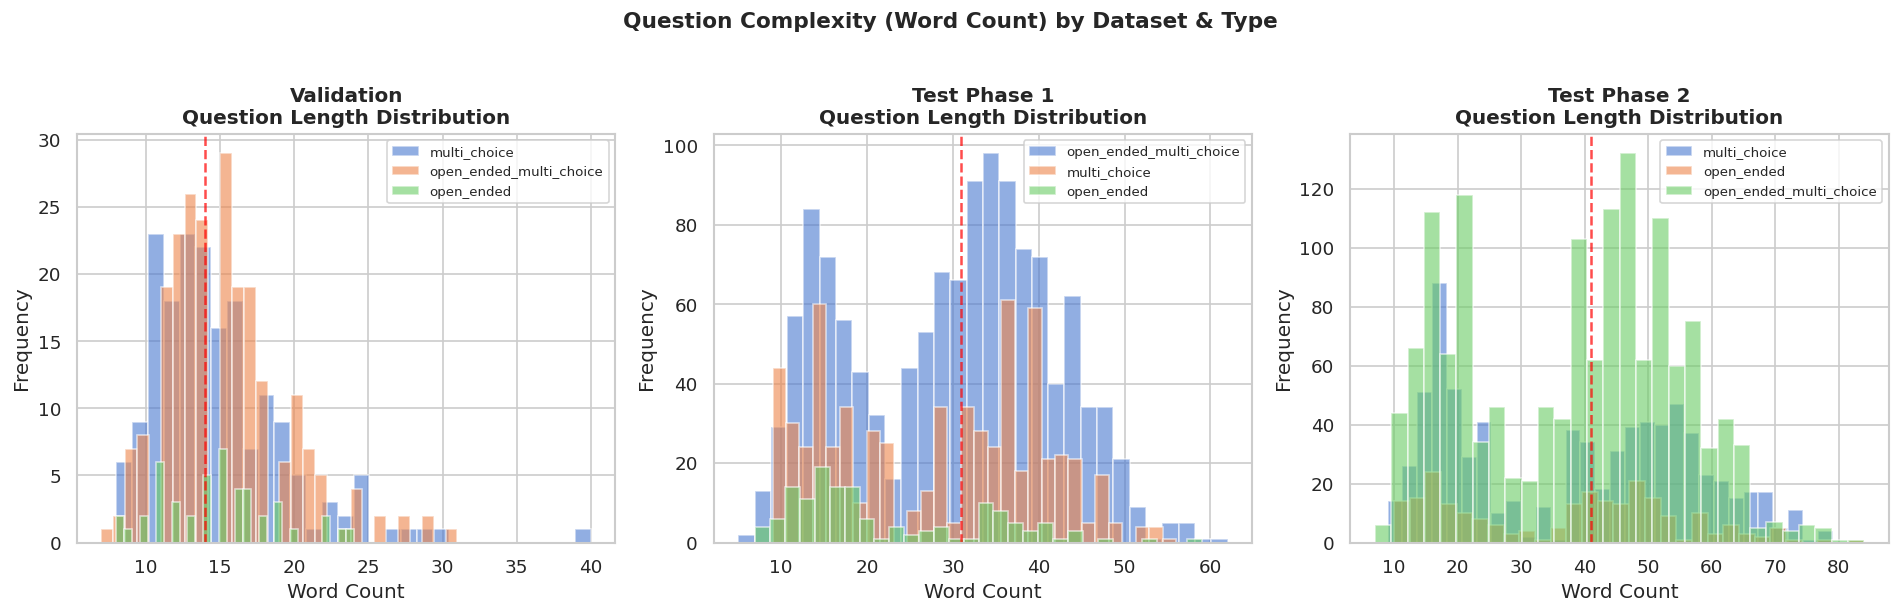

     Dataset  Total Short (≤15w) Medium (16-40w) Long (>40w) Avg Words
  Validation    459    284 (62%)       175 (38%)      0 (0%)      15.1
Test Phase 1   2079    426 (20%)      1303 (63%)   350 (17%)      28.6
Test Phase 2   2491    279 (11%)       953 (38%)  1259 (51%)      37.9

⚠️  Phase 2 has 50%+ long questions. These require multi-step reasoning + tool use.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datasets = [('Validation', val), ('Test Phase 1', test1), ('Test Phase 2', test2)]

for ax, (name, df) in zip(axes, datasets):
    for qtype in df['question_type'].unique():
        subset = df[df['question_type'] == qtype]['q_word_count']
        ax.hist(subset, bins=30, alpha=0.6, label=qtype, edgecolor='white')
    ax.set_title(f'{name}\nQuestion Length Distribution', fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    # Add median line
    ax.axvline(df['q_word_count'].median(), color='red', linestyle='--', alpha=0.7,
               label=f'Median={df["q_word_count"].median():.0f}')

plt.suptitle('Question Complexity (Word Count) by Dataset & Type', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('question_complexity.png', bbox_inches='tight')
plt.show()

# Summary table
complexity_summary = []
for name, df in datasets:
    short  = (df['q_word_count'] <= 15).sum()
    medium = ((df['q_word_count'] > 15) & (df['q_word_count'] <= 40)).sum()
    long_  = (df['q_word_count'] > 40).sum()
    complexity_summary.append({
        'Dataset': name, 'Total': len(df),
        'Short (≤15w)': f'{short} ({short/len(df)*100:.0f}%)',
        'Medium (16-40w)': f'{medium} ({medium/len(df)*100:.0f}%)',
        'Long (>40w)': f'{long_} ({long_/len(df)*100:.0f}%)',
        'Avg Words': f'{df["q_word_count"].mean():.1f}'
    })

summary_df = pd.DataFrame(complexity_summary)
print(summary_df.to_string(index=False))
print('\n⚠️  Phase 2 has 50%+ long questions. These require multi-step reasoning + tool use.')

## 🏥 Step 7 — Patient Scenario Detection

Patient scenario questions are the hardest class — they combine multiple conditions, contraindications, and patient-specific factors. Winning teams found these caused the most failures.

In [ ]:
def is_patient_scenario(q):
    q_low = q.lower()
    return any(kw in q_low for kw in ['year-old', 'patient', 'presents with', 'history of',
                                        'diagnosed with', 'a male', 'a female', 'a woman', 'a man'])

for name, df in datasets:
    patient_q = df['question'].apply(is_patient_scenario)
    count = patient_q.sum()
    print(f'{name:<15s}: {count:,}/{len(df):,} ({count/len(df)*100:.1f}%) are patient scenario questions')

# Show a sample hard question from Phase 2
hard_qs = test2[test2['question'].apply(is_patient_scenario) &
                (test2['q_word_count'] > 60)].head(2)
print('\n=== Sample Hard Questions (Phase 2, long patient scenarios) ===')
for _, row in hard_qs.iterrows():
    print(f'\n[{row["question_type"]}] ({row["q_word_count"]} words)')
    print(f'Q: {row["question"]}')
    print('Options:')
    for k, v in row['options'].items():
        print(f'  {k}: {v}')

Validation     : 154/459 (33.6%) are patient scenario questions
Test Phase 1   : 1,526/2,079 (73.4%) are patient scenario questions
Test Phase 2   : 2,041/2,491 (81.9%) are patient scenario questions

=== Sample Hard Questions (Phase 2, long patient scenarios) ===

[multi_choice] (74 words)
Q: A 32-year-old male presents with severe reactive arthritis characterized by joint swelling, enthesitis, and recurrent aphthous stomatitis. He has a history of Crohn's disease and is currently taking methotrexate. Despite conventional therapy, his symptoms persist. He is not currently on any other biologic agents and has tested negative for latent tuberculosis. Which of the following is the most appropriate drug to initiate for his refractory inflammatory symptoms, considering his current medications and disease profile?
Options:
  A: Renflexis administered intravenously every 8 weeks in combination with methotrexate
  B: Doxycycline hyclate 100 mg orally twice daily
  C: Renflexis administered co

## ☁️ Step 8 — Word Cloud: Most Common Medical Terms

Visualizes which drugs, conditions, and concepts dominate the test set — useful for building your tool query vocabulary.

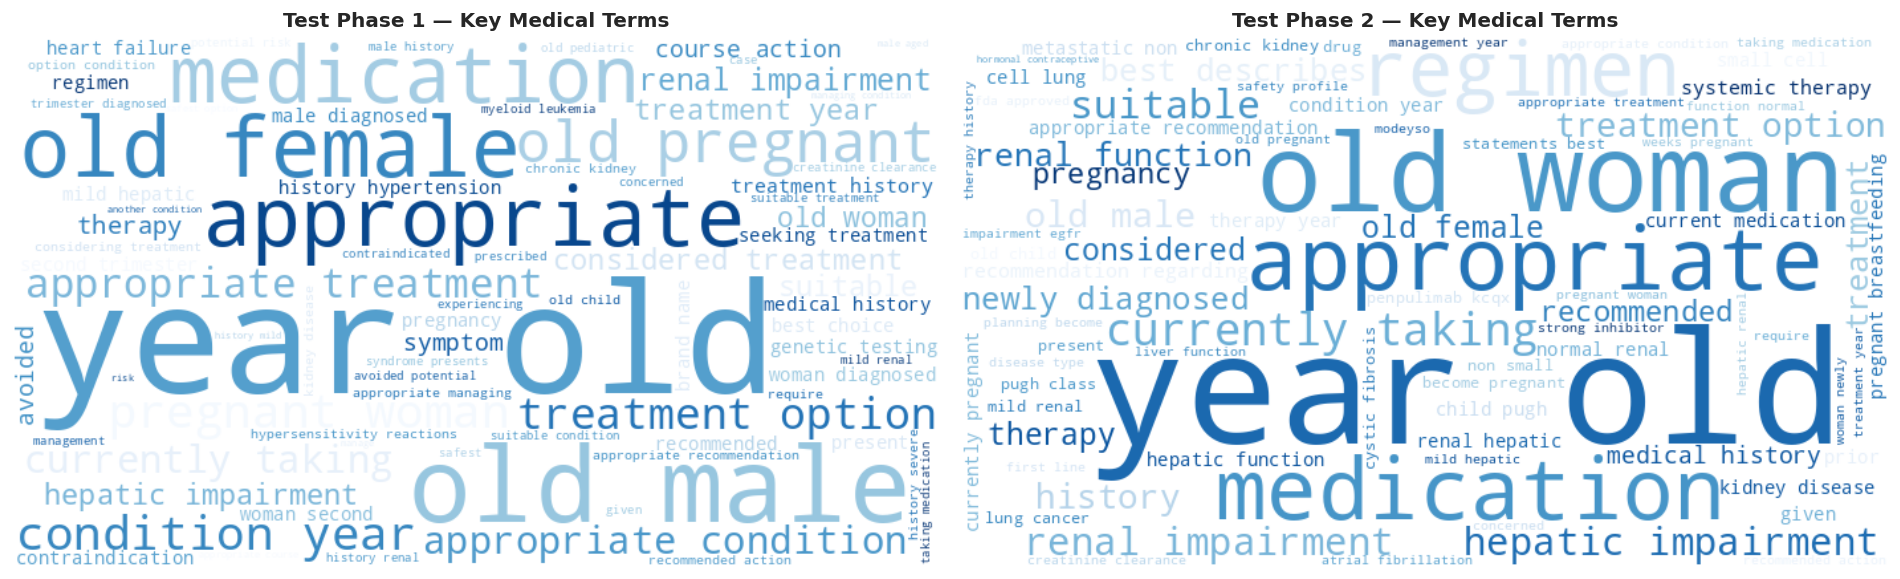

In [ ]:
STOPWORDS = {'the','a','an','is','in','of','to','and','or','for','with','at',
             'from','by','on','be','are','as','it','its','their','which','that',
             'this','what','when','how','if','not','will','should','would','can',
             'do','does','has','have','had','was','were','been','being','may',
             'might','patient','patients','drug','use','used','using','following'}

def get_tokens(df):
    text = ' '.join(df['question'].tolist()).lower()
    tokens = re.findall(r'\b[a-z][a-z-]{3,}\b', text)
    return ' '.join([t for t in tokens if t not in STOPWORDS])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, df) in zip(axes, [('Test Phase 1', test1), ('Test Phase 2', test2)]):
    wc = WordCloud(width=700, height=400, background_color='white',
                   colormap='Blues', max_words=80).generate(get_tokens(df))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{name} — Key Medical Terms', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('word_clouds.png', bbox_inches='tight')
plt.show()

## 📉 Step 9 — Naive Baselines

Before building any agent, establish the **floor** — the score you must beat.

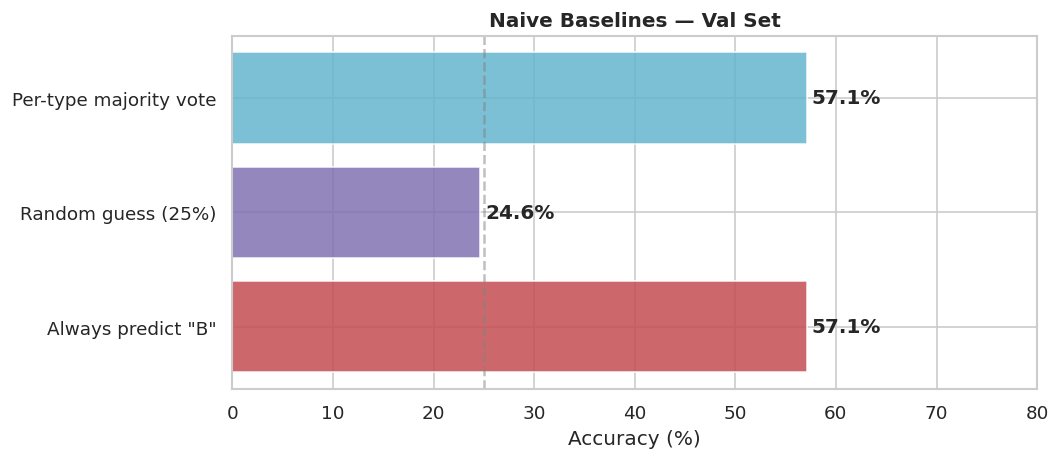


🎯 Your agent must beat all these baselines to demonstrate genuine understanding.
   Target: >60% accuracy on val set to be competitive.


In [ ]:
import random
random.seed(42)

# 1. Always predict most common answer
most_common = val['correct_answer'].mode()[0]
always_b_acc = (val['correct_answer'] == most_common).mean()

# 2. Random guess
options = ['A', 'B', 'C', 'D']
random_preds = [random.choice(options) for _ in range(len(val))]
random_acc = (val['correct_answer'] == pd.Series(random_preds, index=val.index)).mean()

# 3. Random guess per question type
def per_type_majority(df):
    correct = 0
    for qtype in df['question_type'].unique():
        subset = df[df['question_type'] == qtype]
        majority = subset['correct_answer'].mode()[0]
        correct += (subset['correct_answer'] == majority).sum()
    return correct / len(df)

type_majority_acc = per_type_majority(val)

# Display
baselines = {
    f'Always predict "{most_common}"': always_b_acc,
    'Random guess (25%)': random_acc,
    'Per-type majority vote': type_majority_acc,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(baselines.keys()), [v*100 for v in baselines.values()],
               color=['#C44E52','#8172B3','#64B5CD'], alpha=0.85, edgecolor='white')
for bar, acc in zip(bars, baselines.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1%}', va='center', fontweight='bold')
ax.set_xlabel('Accuracy (%)')
ax.set_title('Naive Baselines — Val Set', fontsize=12, fontweight='bold')
ax.set_xlim(0, 80)
ax.axvline(25, color='gray', linestyle='--', alpha=0.5, label='25% random')
plt.tight_layout()
plt.savefig('naive_baselines.png', bbox_inches='tight')
plt.show()

print('\n🎯 Your agent must beat all these baselines to demonstrate genuine understanding.')
print(f'   Target: >60% accuracy on val set to be competitive.')

## 🤖 Step 10 — Zero-Shot LLM Baseline (No Tools)

This is your **ceiling without tools**. Any improvement above this comes from tool augmentation.

> 💡 You need an Anthropic or OpenAI API key. Add it to Colab Secrets: Runtime → Manage Secrets.

In [ ]:
# Install dependencies for Google Gemini API
!pip install google-generativeai -q

# Get API key from Colab secrets (recommended) or paste directly
try:
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get('GeminiAPI')
except:
    GOOGLE_API_KEY = 'your-api-key-here'  # fallback

# Configure the generative AI library
import google.generativeai as genai
genai.configure(api_key=GOOGLE_API_KEY)

print('✅ Google Gemini API ready')

✅ Google Gemini API ready


In [ ]:
import time

# Assuming genai is already configured from the previous cell
# import google.generativeai as genai
# genai.configure(api_key=GOOGLE_API_KEY) # This should already be done in install-anthropic cell

model = genai.GenerativeModel('gemini-3-flash-preview') # Changed model from 'gemini-1.5-flash' to 'gemini-pro'

ZERO_SHOT_PROMPT = """You are a clinical pharmacology expert. Answer the following multiple-choice question.
Respond with ONLY the letter of the correct answer (A, B, C, or D). No explanation.

Question: {question}

Options:
{options}

Answer:"""

def format_options(options_dict):
    return '\n'.join([f'{k}: {v}' for k, v in options_dict.items()])

def zero_shot_predict(row):
    prompt = ZERO_SHOT_PROMPT.format(
        question=row['question'],
        options=format_options(row['options'])
    )
    response = model.generate_content(prompt)
    answer = response.text.strip().upper()
    # Extract just the letter
    match = re.search(r'[ABCD]', answer)
    return match.group(0) if match else 'B'  # fallback to most common

# Run on a sample first (10 questions) to gauge accuracy quickly
SAMPLE_SIZE = 10  # increase to 459 for full eval (costs ~$0.10)
sample = val.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

predictions = []
print(f'Running zero-shot on {SAMPLE_SIZE} questions...')
for i, row in sample.iterrows():
    pred = zero_shot_predict(row)
    predictions.append(pred)
    if (i + 1) % 10 == 0:
        acc = sum(p == t for p, t in zip(predictions, sample['correct_answer'][:len(predictions)])) / len(predictions)
        print(f'  [{i+1}/{SAMPLE_SIZE}] Running accuracy: {acc:.1%}')
    time.sleep(0.2)  # rate limit protection

sample['zero_shot_pred'] = predictions
sample['zero_shot_correct'] = sample['zero_shot_pred'] == sample['correct_answer']

zs_accuracy = sample['zero_shot_correct'].mean()
print(f'\n✅ Zero-shot accuracy (no tools): {zs_accuracy:.1%}')
print(f'   Naive baseline was: {always_b_acc:.1%}')
print(f'   Improvement over naive: +{(zs_accuracy - always_b_acc)*100:.1f}pp')

Running zero-shot on 10 questions...


TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash
Please retry in 8.648280415s.

## 🔬 Step 11 — Error Analysis

This is the **most important step**. Every failure tells you exactly which tool to build.

For each wrong answer, we categorize *why* the LLM failed — this becomes your engineering roadmap.

In [ ]:
errors = sample[~sample['zero_shot_correct']].copy()
print(f'Total errors: {len(errors)} / {SAMPLE_SIZE}')

# Categorize error type
def classify_error_need(row):
    q = row['question'].lower()
    if any(k in q for k in ['brand name', 'generic name', 'drug name', 'associated with']):
        return 'drug_identification → OpenFDA name lookup'
    elif any(k in q for k in ['contraindic', 'should not be used', 'avoid', 'not recommended']):
        return 'contraindication → FDA drug label'
    elif any(k in q for k in ['dose', 'mg', 'administer', 'frequency']):
        return 'dosing_info → DailyMed / FDA label'
    elif any(k in q for k in ['adverse', 'side effect', 'toxicity', 'allergic']):
        return 'adverse_events → OpenFDA FAERS'
    elif any(k in q for k in ['interact', 'combined with', 'concurrent']):
        return 'drug_interaction → DrugBank / OpenFDA'
    elif any(k in q for k in ['pregnan', 'lactat', 'breastfeed']):
        return 'pregnancy_safety → FDA pregnancy category'
    elif any(k in q for k in ['year-old', 'patient', 'presents with']):
        return 'clinical_reasoning → stronger LLM + multi-tool'
    else:
        return 'factual_recall → drug knowledge base'

errors['error_category'] = errors.apply(classify_error_need, axis=1)

# Plot
error_counts = errors['error_category'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(error_counts.index, error_counts.values, color='#C44E52', alpha=0.8, edgecolor='white')
for bar, count in zip(bars, error_counts.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{count} errors', va='center')
ax.set_title('Zero-Shot Error Categories → Tool Building Roadmap', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Errors')
plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

print('\n📋 Sample Errors:')
for _, row in errors.head(5).iterrows():
    print(f'\n  Q: {row["question"][:100]}...')
    print(f'  Predicted: {row["zero_shot_pred"]} | Correct: {row["correct_answer"]}')
    print(f'  Needs: {row["error_category"]}')

## 📋 Step 12 — EDA Summary & Engineering Roadmap

In [ ]:
print('=' * 65)
print('  CUREBENCH EDA SUMMARY')
print('=' * 65)

print(f"""
DATASET SIZES
  Val (labelled):   {len(val):,} questions  ← use for local eval
  Test Phase 1:    {len(test1):,} questions  ← first submission
  Test Phase 2:    {len(test2):,} questions  ← harder, more clinical

QUESTION TYPES (Phase 2 test)
  multi_choice:              {(test2.question_type == 'multi_choice').sum():,} ({(test2.question_type == 'multi_choice').mean():.0%})
  open_ended_multi_choice:   {(test2.question_type == 'open_ended_multi_choice').sum():,} ({(test2.question_type == 'open_ended_multi_choice').mean():.0%})
  open_ended:                {(test2.question_type == 'open_ended').sum():,} ({(test2.question_type == 'open_ended').mean():.0%})

LABEL IMBALANCE (val set)
  Answer B = {(val.correct_answer == 'B').mean():.0%} of all correct answers  ← heavy bias!
  Always-B baseline: {always_b_acc:.1%}  ← your floor

COMPLEXITY SHIFT (val → phase2)
  Val avg question length:     15 words
  Phase 2 avg question length: 38 words  ← 2.5x harder
  Phase 2 clinical scenarios:  80%+ of questions
""")

print('TOOL PRIORITY ORDER (based on topic frequency in test sets)')
print('  1. OpenFDA / DailyMed     → drug labels, contraindications, adverse events')
print('  2. Strong LLM backbone    → clinical scenario reasoning (80% of Phase 2)')
print('  3. DrugBank               → drug interactions, mechanism of action')
print('  4. OpenTargets / Monarch  → gene-disease associations (rare but present)')

print()
print('ARCHITECTURE RECOMMENDATION')
print('  Use Executor-Analyst split (from winning CureAgent team):')
print('  - Executor: TxAgent (tool-calling specialist)')
print('  - Analyst:  Frontier LLM (reasoning + grounding final answer)')
print('  Key risk: Context Utilization Failure (65% of errors in prior work)')
print('  → Analyst must be explicitly instructed to ground answers in tool output')
print('=' * 65)

  CUREBENCH EDA SUMMARY

DATASET SIZES
  Val (labelled):   459 questions  ← use for local eval
  Test Phase 1:    2,079 questions  ← first submission
  Test Phase 2:    2,491 questions  ← harder, more clinical

QUESTION TYPES (Phase 2 test)
  multi_choice:              779 (31%)
  open_ended_multi_choice:   1,474 (59%)
  open_ended:                238 (10%)

LABEL IMBALANCE (val set)
  Answer B = 57% of all correct answers  ← heavy bias!
  Always-B baseline: 57.1%  ← your floor

COMPLEXITY SHIFT (val → phase2)
  Val avg question length:     15 words
  Phase 2 avg question length: 38 words  ← 2.5x harder
  Phase 2 clinical scenarios:  80%+ of questions

TOOL PRIORITY ORDER (based on topic frequency in test sets)
  1. OpenFDA / DailyMed     → drug labels, contraindications, adverse events
  2. Strong LLM backbone    → clinical scenario reasoning (80% of Phase 2)
  3. DrugBank               → drug interactions, mechanism of action
  4. OpenTargets / Monarch  → gene-disease associations (r

## 🚀 Next Steps After EDA

1. **Set up TxAgent** — clone the baseline, run on val set, measure accuracy
2. **Build OpenFDA tool** — covers ~40% of question topics
3. **Run full zero-shot eval** — 459 val questions, not just 50
4. **Implement Executor-Analyst architecture** — decouple tool-calling from reasoning
5. **Add DailyMed tool** — for dosing and specific drug label queries
6. **Eval loop** — track accuracy on val set after each tool addition
7. **Submit to Phase 1** — get official score before building more tools

---
*Generated for CureBench Track 2: Agentic Tool-Augmented Reasoning*